<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/capstone_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from sklearn.decomposition import PCA

# Perform PCA with 2 components for visualization
pca_2_components = PCA(n_components=2)
df_pca_2d = pca_2_components.fit_transform(df_scaled)

# Convert to DataFrame for easier handling
df_pca_2d = pd.DataFrame(data = df_pca_2d, columns = ['principal_component_1', 'principal_component_2'])

print("First 5 rows of PCA with 2 components:")
display(df_pca_2d.head())

First 5 rows of PCA with 2 components:


,principal_component_1,principal_component_2
0,-1.682220,-1.076451
1,-1.138295,2.506477
2,0.969684,-0.383520
3,-0.873628,0.043166
4,-1.599434,-0.688581


In [8]:
# Calculate the covariance matrix of the scaled data
cov_matrix = pd.DataFrame(df_scaled).cov()

# Find the two columns with the highest covariance
# We'll ignore self-covariance (diagonal) and duplicate pairs (upper/lower triangle)
max_cov = 0
col1, col2 = None, None

for i in range(len(cov_matrix.columns)):
    for j in range(i + 1, len(cov_matrix.columns)):
        if abs(cov_matrix.iloc[i, j]) > max_cov:
            max_cov = abs(cov_matrix.iloc[i, j])
            col1 = cov_matrix.columns[i]
            col2 = cov_matrix.columns[j]

print(f"The two columns with the most covariance are '{col1}' and '{col2}' with a covariance of {max_cov:.4f}.")

The two columns with the most covariance are 'PURCHASES' and 'ONEOFF_PURCHASES' with a covariance of 0.9169.


In [9]:
# Interpret the results of PCA by looking at the covariance matrix
# The get_covariance() method returns the covariance matrix of the original data projected into the PCA space.
# However, the user is likely asking for the covariance matrix of the *transformed* data, or to interpret the components.
# Let's assume the user is interested in the covariance of the principal components themselves.
# For the PCA with 2 components, the covariance matrix of the principal components is simply its explained variance.
# For the pca_full object (with all components), we can look at the covariance of the scaled data in the PCA's projection space.

# Covariance matrix of the original scaled features as seen by PCA_full
print("\nCovariance matrix of the original scaled features (estimated by PCA_full):")
display(pd.DataFrame(pca_full.get_covariance(), columns=df_scaled.columns, index=df_scaled.columns).head())


Covariance matrix of the original scaled features (estimated by PCA_full):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000112,0.322448,0.181281,0.164368,0.126483,0.496747,-0.077952,0.073174,-0.063193,0.449268,0.385195,0.154356,0.531326,0.322838,0.394326,-0.318995,0.072700
BALANCE_FREQUENCY,0.322448,1.000112,0.133689,0.104335,0.124306,0.099399,0.229741,0.202438,0.176099,0.191894,0.141571,0.189647,0.095805,0.065015,0.114262,-0.095093,0.119789
PURCHASES,0.181281,0.133689,1.000112,0.916947,0.679972,-0.051480,0.393061,0.498485,0.315602,-0.120157,-0.067183,0.689638,0.356999,0.603331,0.093525,0.180399,0.086298
ONEOFF_PURCHASES,0.164368,0.104335,0.916947,1.000112,0.330658,-0.031329,0.264967,0.524950,0.127743,-0.082637,-0.046217,0.545584,0.319757,0.567355,0.048603,0.132778,0.064157
INSTALLMENTS_PURCHASES,0.126483,0.124306,0.679972,0.330658,1.000112,-0.064251,0.442467,0.214066,0.511408,-0.132333,-0.074007,0.628178,0.256525,0.384127,0.131702,0.182590,0.086153


In [4]:
from sklearn.preprocessing import StandardScaler

# Drop the 'CUST_ID' column as it's not a numerical feature
df_scaled = df.drop('CUST_ID', axis=1)

# Perform feature scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_scaled)

# Convert the scaled array back to a DataFrame for easier handling if needed, though not strictly necessary for PCA
df_scaled = pd.DataFrame(df_scaled, columns=df.drop('CUST_ID', axis=1).columns)

print("First 5 rows of the scaled DataFrame:")
display(df_scaled.head())

First 5 rows of the scaled DataFrame:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


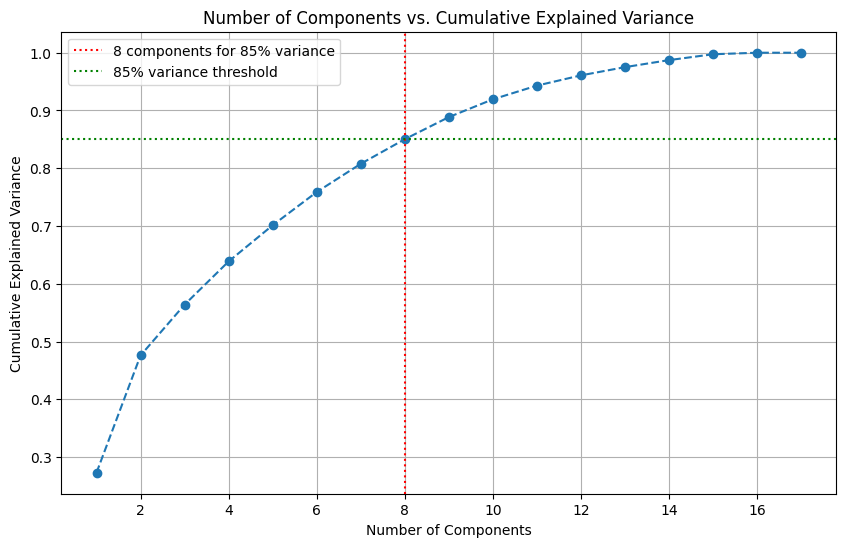

Number of components required to cover 85% of the variance: 8


In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA with all components
pca_full = PCA()
pca_full.fit(df_scaled)

# Calculate cumulative explained variance
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

# Plot number of components vs. PCA cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Number of Components vs. Cumulative Explained Variance')
plt.grid(True)

# Identify the number of components for 85% variance
components_85_variance = next(i for i, total_variance in enumerate(cumulative_variance) if total_variance >= 0.85) + 1
plt.axvline(x=components_85_variance, color='r', linestyle=':', label=f'{components_85_variance} components for 85% variance')
plt.axhline(y=0.85, color='g', linestyle=':', label='85% variance threshold')
plt.legend()
plt.show()

print(f"Number of components required to cover 85% of the variance: {components_85_variance}")

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/CC GENERAL.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [2]:
# Check for null values
print("\nNull values before handling:")
display(df.isnull().sum())


Null values before handling:


,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [6]:
# Handle null values
# For simplicity, let's fill numerical columns with their mean.
# 'CREDIT_LIMIT' and 'MINIMUM_PAYMENTS' are the columns with null values.
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean())

print("\nNull values after handling:")
display(df.isnull().sum())


Null values after handling:


,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


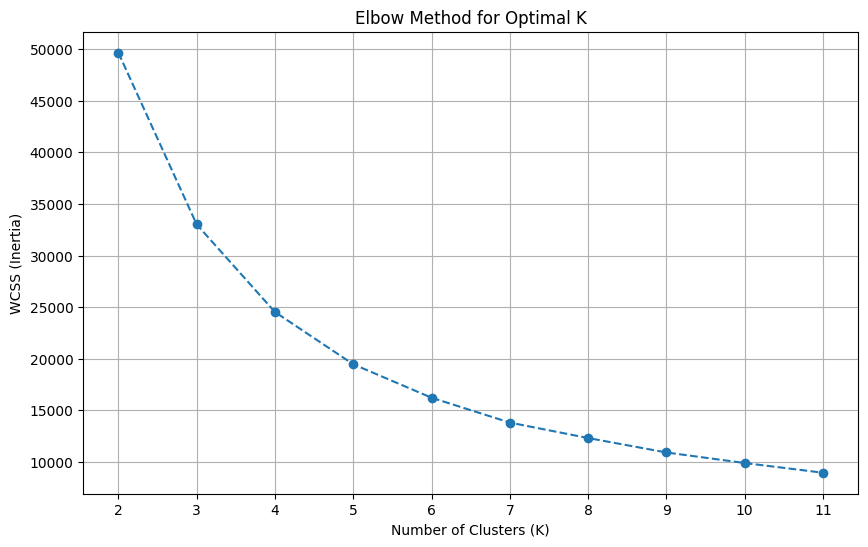

Please examine the plot and identify the 'elbow point' to determine the ideal number of clusters. Then, I can proceed with the next step.


In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS (Within-Cluster Sum of Squares) for different number of clusters
wcss = []
for i in range(2, 12): # Clusters ranging from 2 to 11
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_pca_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 12), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.xticks(range(2, 12))
plt.show()

print("Please examine the plot and identify the 'elbow point' to determine the ideal number of clusters. Then, I can proceed with the next step.")